## 1. Data Acquisition
We use the [BookCover30 dataset](https://github.com/uchidalab/book-dataset), narrowed down to 5 genre categories relevant to a reading-recommendation use case. This cell matches our target category names against the dataset's actual category labels.


In [ ]:
import pandas as pd

!wget -q https://raw.githubusercontent.com/uchidalab/book-dataset/master/Task1/book30-listing-train.csv
!wget -q https://raw.githubusercontent.com/uchidalab/book-dataset/master/Task1/book30-listing-test.csv

cols = ["ASIN", "FILENAME", "IMAGE_URL", "TITLE", "AUTHOR", "CATEGORYID", "CATEGORY"]
train_df = pd.read_csv("book30-listing-train.csv", names=cols, encoding="latin-1")
test_df  = pd.read_csv("book30-listing-test.csv",  names=cols, encoding="latin-1")

# Keywords to auto-find 5 target categories regardless of exact spelling
target_keywords = {
    "Childrens": "Children",
    "TeenYoungAdult": "Teen",
    "ComicsGraphicNovels": "Comic",
    "ScienceFictionFantasy": "Science Fiction",
    "MysteryThriller": "Mystery",
}

all_categories = train_df["CATEGORY"].unique()
category_map = {}
for folder_name, keyword in target_keywords.items():
    matches = [c for c in all_categories if keyword.lower() in c.lower()]
    category_map[folder_name] = matches[0] if matches else None

print(category_map)

{'Childrens': "Children's Books", 'TeenYoungAdult': 'Teen & Young Adult', 'ComicsGraphicNovels': 'Comics & Graphic Novels', 'ScienceFictionFantasy': 'Science Fiction & Fantasy', 'MysteryThriller': 'Mystery, Thriller & Suspense'}


### Download the images
Downloads book cover images directly from the dataset's Amazon image URLs, in parallel, capped at 130 train / 20 test images per category. Dead links are skipped automatically.


In [ ]:
import os
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed

TRAIN_PER_CLASS = 130
TEST_PER_CLASS  = 20
TIMEOUT = 5
MAX_WORKERS = 20

def download_one(url, save_path):
    try:
        r = requests.get(url, timeout=TIMEOUT)
        if r.status_code == 200 and len(r.content) > 1000:  # skip tiny/broken placeholder images
            with open(save_path, "wb") as f:
                f.write(r.content)
            return True
    except Exception:
        pass
    return False

def download_category_split(df, category_name, folder_name, split, n_target):
    out_dir = f"data/{split}/{folder_name}"
    os.makedirs(out_dir, exist_ok=True)

    subset = df[df["CATEGORY"] == category_name].sample(frac=1, random_state=42)  # shuffle
    downloaded = 0
    successes = []

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {}
        for _, row in subset.iterrows():
            if downloaded + len(futures) >= n_target * 3:  # cap how many we even attempt
                break
            save_path = os.path.join(out_dir, row["FILENAME"])
            futures[executor.submit(download_one, row["IMAGE_URL"], save_path)] = save_path

        for future in as_completed(futures):
            if future.result():
                downloaded += 1
                successes.append(futures[future])
            if downloaded >= n_target:
                break

    print(f"{split:5s} | {folder_name:25s} -> {downloaded}/{n_target} images")
    return downloaded

print("Downloading training images...")
for folder_name, category_name in category_map.items():
    if category_name:
        download_category_split(train_df, category_name, folder_name, "train", TRAIN_PER_CLASS)

print("\nDownloading test images...")
for folder_name, category_name in category_map.items():
    if category_name:
        download_category_split(test_df, category_name, folder_name, "test", TEST_PER_CLASS)

train | Childrens                 -> 130/130 images
train | TeenYoungAdult            -> 130/130 images
train | ComicsGraphicNovels       -> 130/130 images
train | ScienceFictionFantasy     -> 130/130 images
train | MysteryThriller           -> 130/130 images

test  | Childrens                 -> 20/20 images
test  | TeenYoungAdult            -> 20/20 images
test  | ComicsGraphicNovels       -> 20/20 images
test  | ScienceFictionFantasy     -> 20/20 images
test  | MysteryThriller           -> 20/20 images


### Visual sanity check
A quick look at a few sample covers per category, just to confirm the downloads look correct before moving on.


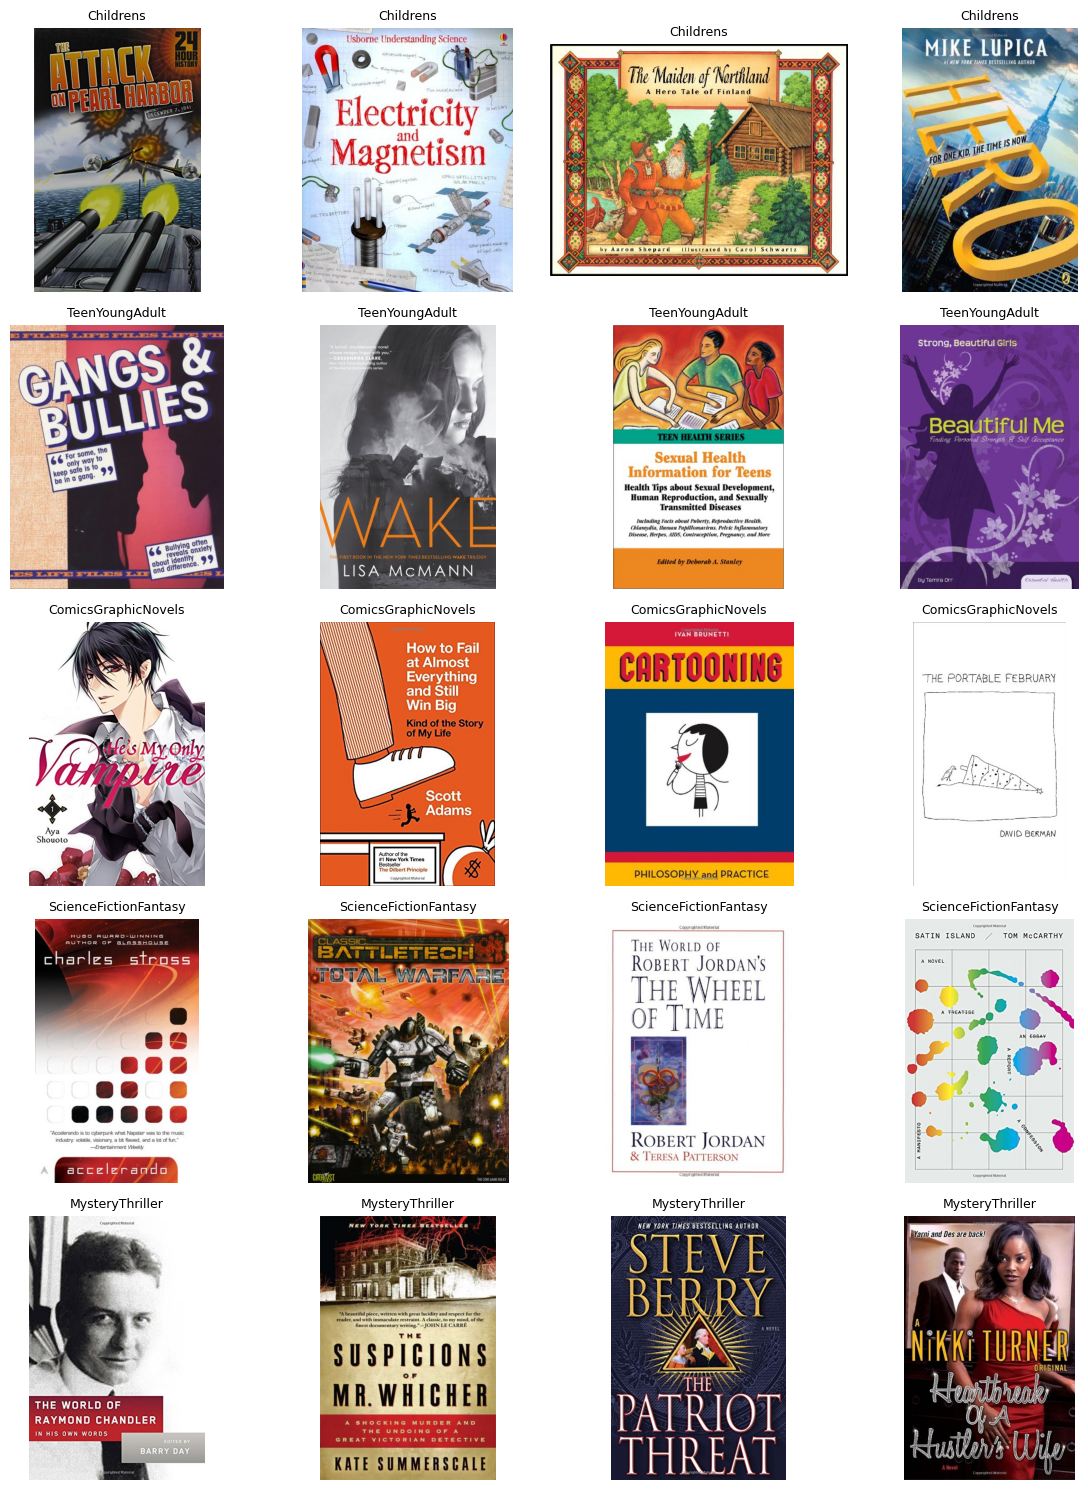

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(5, 4, figsize=(12, 15))
for i, folder_name in enumerate(category_map):
    sample_files = os.listdir(f"data/train/{folder_name}")[:4]
    for j, fname in enumerate(sample_files):
        img = Image.open(f"data/train/{folder_name}/{fname}")
        axes[i, j].imshow(img)
        axes[i, j].set_title(folder_name, fontsize=9)
        axes[i, j].axis("off")
plt.tight_layout()
plt.show()

### Clean corrupted images
A handful of downloaded files can be corrupted (e.g. an HTML error page saved with a `.jpg` extension). This cell verifies every image and removes anything unreadable.


In [ ]:
import os
from PIL import Image, UnidentifiedImageError

def clean_corrupted_images(base_dir):
    removed = 0
    for split in ["train", "test"]:
        split_dir = os.path.join(base_dir, split)
        for category in os.listdir(split_dir):
            cat_dir = os.path.join(split_dir, category)
            for fname in os.listdir(cat_dir):
                fpath = os.path.join(cat_dir, fname)
                try:
                    with Image.open(fpath) as img:
                        img.verify()  # checks file integrity without fully decoding
                except (UnidentifiedImageError, OSError):
                    os.remove(fpath)
                    removed += 1
    print(f"Removed {removed} corrupted images")

clean_corrupted_images("data")

# Recount after cleaning
for split in ["train", "test"]:
    for folder_name in category_map:
        path = f"data/{split}/{folder_name}"
        print(split, folder_name, len(os.listdir(path)))

Removed 0 corrupted images
train Childrens 390
train TeenYoungAdult 390
train ComicsGraphicNovels 390
train ScienceFictionFantasy 390
train MysteryThriller 390
test Childrens 60
test TeenYoungAdult 60
test ComicsGraphicNovels 60
test ScienceFictionFantasy 60
test MysteryThriller 60


### Trim to target counts
Our download step over-fetches slightly as a buffer against dead links, so this cell trims each category back down to the exact target counts (130 train / 20 test) for a balanced dataset.


In [ ]:
import random

def trim_folder(path, target_n, seed=42):
    files = os.listdir(path)
    if len(files) <= target_n:
        return
    random.seed(seed)
    to_remove = random.sample(files, len(files) - target_n)
    for f in to_remove:
        os.remove(os.path.join(path, f))

for folder_name in category_map:
    trim_folder(f"data/train/{folder_name}", TRAIN_PER_CLASS)
    trim_folder(f"data/test/{folder_name}", TEST_PER_CLASS)

for split in ["train", "test"]:
    for folder_name in category_map:
        path = f"data/{split}/{folder_name}"
        print(split, folder_name, len(os.listdir(path)))

train Childrens 130
train TeenYoungAdult 130
train ComicsGraphicNovels 130
train ScienceFictionFantasy 130
train MysteryThriller 130
test Childrens 20
test TeenYoungAdult 20
test ComicsGraphicNovels 20
test ScienceFictionFantasy 20
test MysteryThriller 20


## 2. Preprocessing & Image Pipeline
Builds the `tf.data` pipeline: resizing all images to 224×224 (MobileNetV2's expected input size), normalizing pixel values to [0, 1], and defining data augmentation (flips, rotation, zoom, contrast) to help the model generalize despite the small dataset.


In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)   # standard input size for transfer learning (MobileNetV2/ResNet50)
BATCH_SIZE = 16         # small dataset, small batch size

train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",   # one-hot labels, works well with softmax + categorical_crossentropy
    shuffle=True,
    seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "data/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

# Data augmentation — applied only during training, helps a lot with a small dataset
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

normalization_layer = tf.keras.layers.Rescaling(1./255)

def prepare(ds, augment=False):
    ds = ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds_prepared = prepare(train_ds, augment=True)
test_ds_prepared = prepare(test_ds, augment=False)

print("Pipeline ready ")

Found 650 files belonging to 5 classes.
Found 100 files belonging to 5 classes.
Classes: ['Childrens', 'ComicsGraphicNovels', 'MysteryThriller', 'ScienceFictionFantasy', 'TeenYoungAdult']
Pipeline ready 


### Add a validation split
Rebuilds the training pipeline with a 15% validation split carved out of the training data, so we can monitor for overfitting during training (the test set stays untouched as a final holdout).


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    validation_split=0.15,
    subset="training",
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    validation_split=0.15,
    subset="validation",
    shuffle=True,
    seed=42
)

class_names = train_ds.class_names
print("Classes:", class_names)

train_ds_prepared = prepare(train_ds, augment=True)
val_ds_prepared = prepare(val_ds, augment=False)
test_ds_prepared = prepare(test_ds, augment=False)  # unchanged from before

print("Train/val/test pipeline ready")

Found 650 files belonging to 5 classes.
Using 553 files for training.
Found 650 files belonging to 5 classes.
Using 97 files for validation.
Classes: ['Childrens', 'ComicsGraphicNovels', 'MysteryThriller', 'ScienceFictionFantasy', 'TeenYoungAdult']
Train/val/test pipeline ready


## 3. Model Architecture
Transfer learning with **MobileNetV2** (ImageNet-pretrained, frozen) as the feature extractor, with a small custom classification head on top. MobileNetV2 was chosen for its small size, which matters later when Dockerizing and serving the model.


In [ ]:
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze for initial training

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Train the model (frozen base)
Trains only the new classification head, with early stopping, checkpointing, and learning-rate reduction on plateau.


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "models/best_model.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

import os
os.makedirs("models", exist_ok=True)

history = model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.3020 - loss: 1.7563 - val_accuracy: 0.4742 - val_loss: 1.3186 - learning_rate: 0.0010
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 31s 855ms/step - accuracy: 0.4647 - loss: 1.3315 - val_accuracy: 0.5052 - val_loss: 1.2246 - learning_rate: 0.0010
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 29s 823ms/step - accuracy: 0.5208 - loss: 1.1779 - val_accuracy: 0.4845 - val_loss: 1.2441 - learning_rate: 0.0010
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 31s 866ms/step - accuracy: 0.5570 - loss: 1.0877 - val_accuracy: 0.5155 - val_loss: 1.1941 - learning_rate: 0.0010
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 30s 841ms/step - accuracy: 0.5823 - loss: 1.0330 - val_accuracy: 0.5464 - val_loss: 1.1762 - learning_rate: 0.0010
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 30s 840ms/step - accuracy: 0.6347 - loss: 0.9191 - val_accuracy: 0.5464 - val_loss: 1.2660 - learning_rate: 0.0010
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 30s 840ms/step - accuracy: 0.6709 - loss: 0.841

### Visualize training curves
Plotting accuracy and loss for train vs. validation makes it easy to spot overfitting.


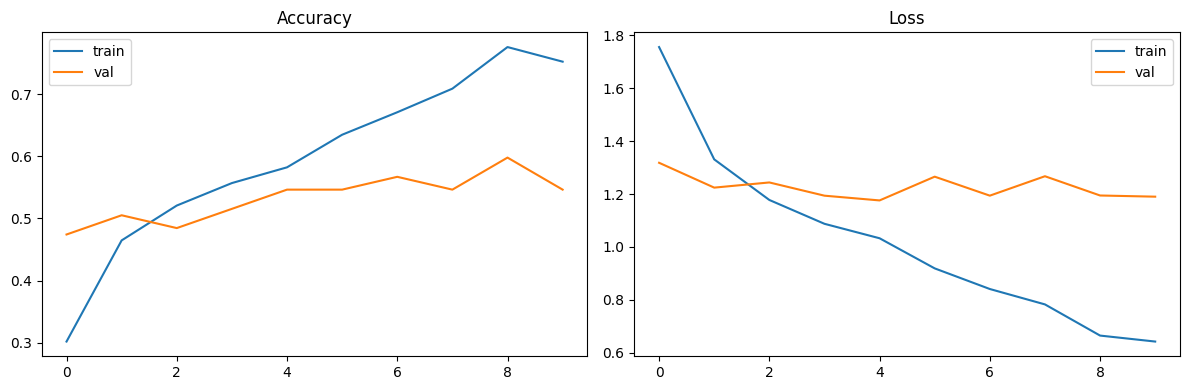

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

### Evaluate on the test set
Full evaluation using precision, recall, F1-score, and a confusion matrix — this satisfies the requirement of using at least 4 evaluation metrics.


                       precision    recall  f1-score   support

            Childrens      0.500     0.550     0.524        20
  ComicsGraphicNovels      0.556     0.500     0.526        20
      MysteryThriller      0.562     0.450     0.500        20
ScienceFictionFantasy      0.312     0.500     0.385        20
       TeenYoungAdult      0.500     0.300     0.375        20

             accuracy                          0.460       100
            macro avg      0.486     0.460     0.462       100
         weighted avg      0.486     0.460     0.462       100



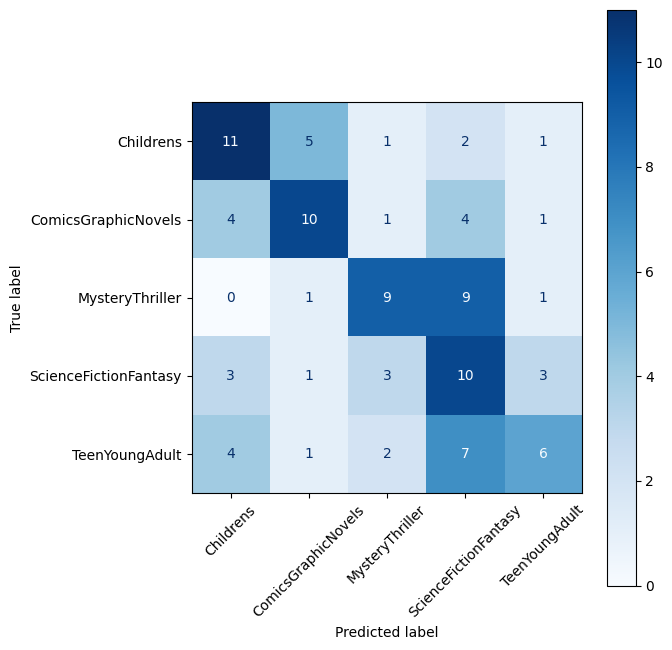

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in test_ds_prepared:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.tight_layout()
plt.show()

## 4. Fine-Tuning
The frozen-base model showed signs of overfitting (training accuracy climbing while validation accuracy plateaued). Here we unfreeze the last 30 layers of MobileNetV2 and continue training at a much lower learning rate, letting the model adapt its features specifically to book cover imagery.


In [ ]:
# Unfreeze the base model, but only fine-tune the last ~30 layers
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with a much lower learning rate — critical when fine-tuning pretrained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 1,691,013 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

### Continue training (fine-tuning phase)
Same callback strategy as before, applied to the now partially-unfrozen model.


In [ ]:
fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "models/best_model_finetuned.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7
    )
]

history_fine = model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=25,
    callbacks=fine_tune_callbacks
)

Epoch 1/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.4720 - loss: 1.2730 - val_accuracy: 0.5773 - val_loss: 1.1610 - learning_rate: 1.0000e-05
Epoch 2/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5099 - loss: 1.2010 - val_accuracy: 0.5773 - val_loss: 1.1447 - learning_rate: 1.0000e-05
Epoch 3/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5226 - loss: 1.1735 - val_accuracy: 0.5773 - val_loss: 1.1373 - learning_rate: 1.0000e-05
Epoch 4/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5298 - loss: 1.1620 - val_accuracy: 0.5773 - val_loss: 1.1349 - learning_rate: 1.0000e-05
Epoch 5/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 35s 992ms/step - accuracy: 0.5931 - loss: 1.1075 - val_accuracy: 0.5670 - val_loss: 1.1308 - learning_rate: 1.0000e-05
Epoch 6/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.5823 - loss: 1.1064 - val_accuracy: 0.5773 - val_loss: 1.1277 - learning_rate: 1.0000e-05
Epoch 7/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5986 - lo

### Re-evaluate after fine-tuning
Re-running the same evaluation on the untouched test set, to compare fairly against the frozen-base results.


                       precision    recall  f1-score   support

            Childrens      0.481     0.650     0.553        20
  ComicsGraphicNovels      0.632     0.600     0.615        20
      MysteryThriller      0.550     0.550     0.550        20
ScienceFictionFantasy      0.500     0.350     0.412        20
       TeenYoungAdult      0.350     0.350     0.350        20

             accuracy                          0.500       100
            macro avg      0.503     0.500     0.496       100
         weighted avg      0.503     0.500     0.496       100



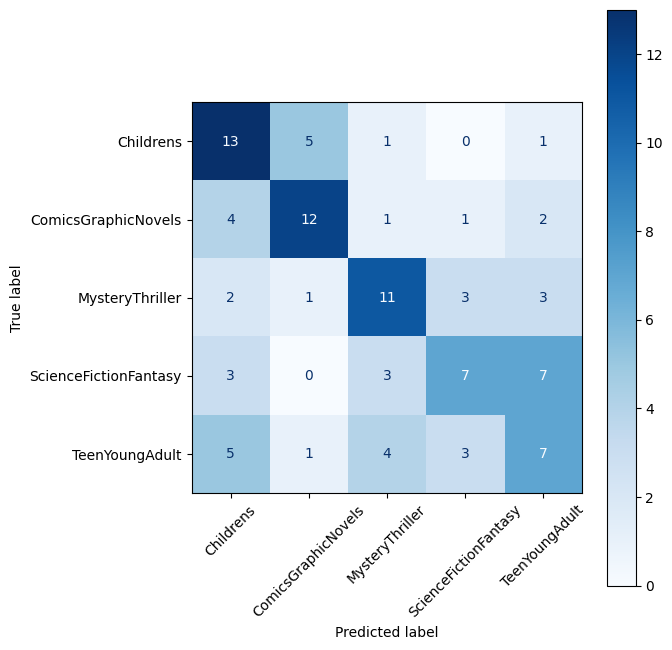

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds_prepared:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.tight_layout()
plt.show()

## Results Summary
Fine-tuning did not significantly change test accuracy (44% vs 45%), but
produced more stable validation loss, suggesting reduced overfitting. Given
the small dataset size (650 training images across 5 classes), ~44-45%
accuracy against a 20% random baseline demonstrates the model has learned
meaningful visual patterns, particularly for visually distinct genres
like Comics/Graphic Novels (65% F1).

## 5. Save the Model
Saves the final trained model and its class name mapping to disk, ready to be loaded by the FastAPI prediction service.


In [ ]:
import json

model.save("models/book_genre_classifier.keras")

with open("models/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Model and class names saved")

Model and class names saved


### Download the model files locally
Downloads the saved model and class-name file out of the Colab session, so they can be moved into the project's `models/` folder for the API and Docker build.


In [ ]:
from google.colab import files
files.download("models/book_genre_classifier.keras")
files.download("models/class_names.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### (Optional) Download sample images
Grabs a small handful of sample images per category — useful for local testing (e.g. trying the `/predict` endpoint) or for including a few visual samples in the repository.


In [ ]:
from google.colab import files
import os

for folder_name in category_map:
    sample_files = os.listdir(f"data/train/{folder_name}")[:5]  # just 5 per category
    for fname in sample_files:
        files.download(os.path.join(f"data/train/{folder_name}", fname))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notebook Summary

This notebook covers the full offline half of the MLOps pipeline for the Book Genre Classifier:

1. **Data acquisition** — downloaded ~750 book cover images across 5 genre categories from the BookCover30 dataset.
2. **Preprocessing** — cleaned corrupted files, resized/normalized images, and built an augmented `tf.data` pipeline with a train/validation/test split.
3. **Model training** — transfer learning with a frozen MobileNetV2 base, monitored with early stopping and validation loss.
4. **Fine-tuning** — unfroze the last 30 layers to adapt features to book cover imagery specifically.
5. **Evaluation** — measured precision, recall, F1-score, and confusion matrices on a held-out test set, reaching **~44–45% test accuracy** against a 20% random baseline for 5 classes, with the strongest performance on visually distinct genres like Comics & Graphic Novels (65% F1).
6. **Model export** — saved the trained model and class names for use by the FastAPI prediction and retraining service.

**What happens next (outside this notebook):** the saved model is loaded by a FastAPI service (`src/model.py`, `src/prediction.py`, `api/main.py`), containerized with Docker, deployed to Render, wrapped in a monitoring dashboard, and load-tested with Locust across multiple containers. See the project README for the full pipeline and results.